In [1]:
import pandas as pd

df = pd.read_csv("../Dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [3]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [ ]:
df['Attrition'].value_counts()  #this shows how many stayed that is 1233 and 237 left

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [ ]:
#First KPI- shows us that out of 100 employees 16 leave the company
attrition_rate=(
    df['Attrition'].value_counts()['Yes']
    /len(df)
) * 100
print(f"Attrition Rate:{attrition_rate:.2f}%") 

Attrition Rate:16.12%


In [8]:
#Total employee KPI
total_employee=len(df)
print(total_employee)

1470


In [9]:
df['Age'].mean()

np.float64(36.923809523809524)

In [10]:
df['Department'].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [11]:
#analysis 1
pd.crosstab(
    df['Department'],
    df['Attrition']
)

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [ ]:
department_attrition=pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) *100
department_attrition #% gives us real picture how even tho sales has less employee they are leaving rhe most 20%


Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [15]:
#To check if employes working overtime leave more often
pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
) *100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [16]:
#To check average salary of employees who left
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [18]:
#Job satisfaction vs our attrition
pd.crosstab(
    df['JobSatisfaction'],
    df['Attrition'],
    normalize='index'
) *100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


# Business Insights

## Insight 1: Overall Attrition
The company's attrition rate is 16.12%.
This means approximately 16 out of every 100 employees leave the organization.

## Insight 2: Department-wise Attrition
The Sales department experiences the highest attrition rate at approximately 20.63%, followed by Human Resources at 19.05%.

Business Impact:
High employee turnover in Sales can affect revenue generation, customer relationships, and increase hiring costs.

## Insight 3: Overtime Impact
Employees who work overtime have an attrition rate of 30.53%, compared to only 10.44% for employees who do not work overtime.

Business Impact:
Work-life imbalance appears to be a major contributor to employee turnover.

## Insight 4: Salary Impact
Employees who left the company earned an average monthly income of ₹4,787, while employees who stayed earned an average monthly income of ₹6,833.

Business Impact:
Lower compensation may be a significant factor influencing attrition.
 


In [ ]:
#This shows which role tends to leave the most
pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) *100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [21]:
#Create age groups
df['AgeGroup']=pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

In [ ]:
#shows us if younger employess are leaving more frequntly
pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
) *100

Attrition,No,Yes
AgeGroup,,
18-25,65.217391,34.782609
26-35,80.858086,19.141914
36-45,90.811966,9.188034
46-55,88.495575,11.504425
56-65,82.978723,17.021277


## Insight 5: Job Satisfaction Impact

Employees with the lowest job satisfaction score (1) have an attrition rate of 22.84%, while employees with the highest satisfaction score (4) have an attrition rate of only 11.33%.

Business Impact:
Employee satisfaction has a strong negative relationship with attrition. As job satisfaction increases, employee turnover decreases.

Recommendation:
Conduct employee satisfaction surveys and address workplace concerns proactively.

# Executive Summary

The organization experiences an attrition rate of 16.12%.

Analysis revealed five major drivers of employee attrition:

1. Employees working overtime are significantly more likely to leave.
2. Sales department experiences the highest attrition.
3. Sales Representatives show the highest turnover among job roles.
4. Younger employees (18-25 years) leave more frequently.
5. Employees with lower salaries and lower job satisfaction are more likely to resign.

These findings indicate that workload, compensation, career growth, and employee engagement are major contributors to attrition.

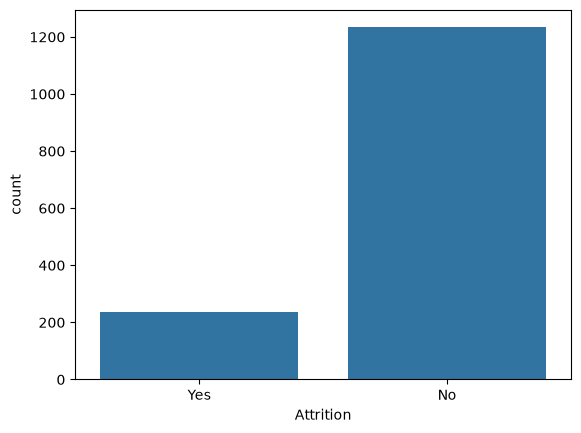

In [ ]:
#Attrition Count
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Attrition')
plt.show()

<Axes: xlabel='Department', ylabel='count'>

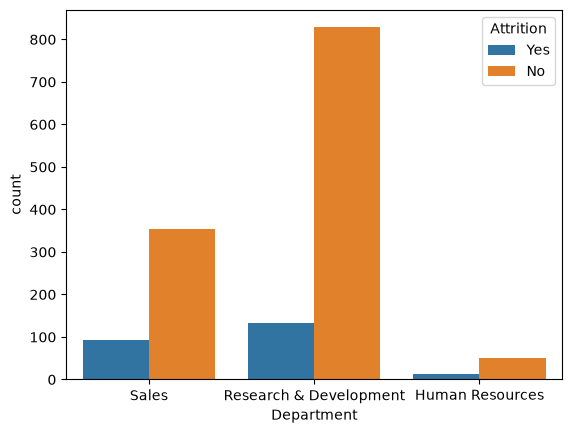

In [25]:
#Attrition by department
sns.countplot(
    data=df,
    x='Department',
    hue='Attrition'
)

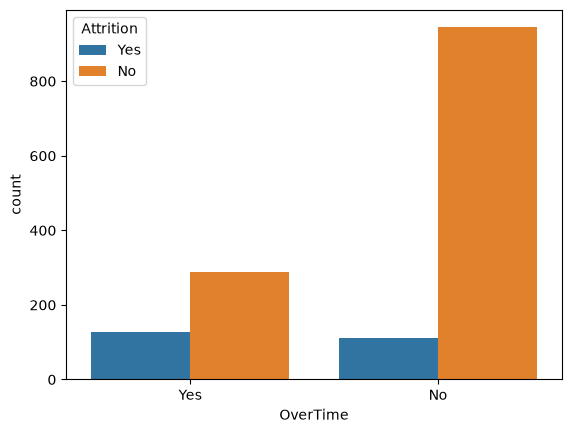

In [ ]:
#Attrition by overtime
sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.show()

<Axes: xlabel='Age', ylabel='Count'>

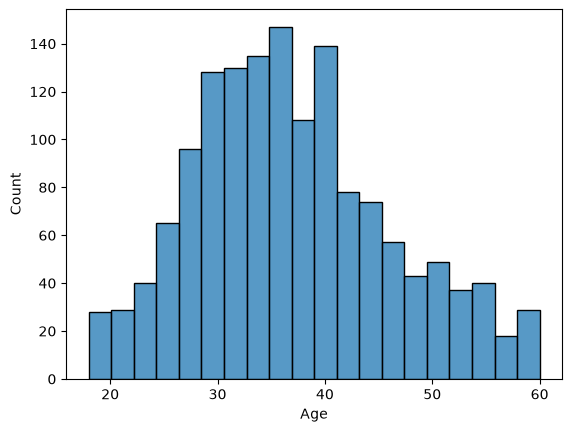

In [28]:
#Attrition by age
sns.histplot(
    data=df,
    x='Age',
    bins=20
)